In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
#from sklearn import metrics 
from xailib.data_loaders.dataframe_loader import prepare_dataframe

 
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
 
from sklearn.compose import make_column_selector as selector

from lore_sa.dataset import TabularDataset

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

2024-05-23 10:59:47,914 matplotlib   DEBUG    matplotlib data path: /opt/anaconda3/envs/xai/lib/python3.8/site-packages/matplotlib/mpl-data
2024-05-23 10:59:47,921 matplotlib   DEBUG    CONFIGDIR=/Users/eleonoracappuccio/.matplotlib
2024-05-23 10:59:47,926 matplotlib   DEBUG    interactive is False
2024-05-23 10:59:47,927 matplotlib   DEBUG    platform is darwin
2024-05-23 10:59:48,000 matplotlib   DEBUG    CACHEDIR=/Users/eleonoracappuccio/.matplotlib
2024-05-23 10:59:48,004 matplotlib.font_manager DEBUG    Using fontManager instance from /Users/eleonoracappuccio/.matplotlib/fontlist-v330.json


In [2]:
df = pd.read_csv("../../datasets/Final_data.csv")
 
df = df.loc[:,['Class_label','Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week5_Mobility','Week4_Mobility','Week3_Mobility','Week2_Mobility', 'Days_passed', 'Duration']]
 
mask = df.drop(["Class_label"], axis=1).isna().all(axis=1) & df['Class_label'].notna()
result_df = df[~mask]
#df = df.dropna(how = 'all')
result_df = result_df.fillna("NONE")


In [3]:
result_df.head()

,Class_label,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,c1,c4,c4,c3,m1,m1,m1,m1,63.0,84
1,c2,c4,c4,c4,m4,m1,m1,m1,56.0,7
2,c2,c1,c1,c1,m3,m3,m3,m3,147.0,14
3,c3,c2,c3,c4,m4,m4,m4,m1,42.0,14
4,c3,c1,c1,c1,m3,m3,m3,m3,161.0,14


In [4]:
y = result_df["Class_label"].values
X_feat = result_df.loc[:,'Week5_Covid':'Duration']

In [5]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

In [6]:
numerical_columns = numerical_columns_selector(X_feat)
categorical_columns = categorical_columns_selector(X_feat)

In [7]:
covid_categories = ['NONE', 'c1', 'c2', 'c3', 'c4']
mobility_categories = ['NONE','m1', 'm2', 'm3', 'm4']
 
enc = OrdinalEncoder(categories=[covid_categories,covid_categories,covid_categories, mobility_categories,mobility_categories,mobility_categories,mobility_categories])
numerical_preprocessor = StandardScaler()

In [8]:
preprocessor = ColumnTransformer(
    [
        ("ordinal-encoder", enc, categorical_columns),
        ("standard_scaler", numerical_preprocessor, numerical_columns),
    ]
)

In [9]:
clf = RandomForestClassifier(n_estimators = 100, random_state=0)
model = make_pipeline(preprocessor, clf)
 
#y_prediction = cross_val_predict(model, X_feat,y, cv=5)
#acc = cross_val_score(model, X_feat,y, cv=5)

In [10]:
data_train, data_test, target_train, target_test = train_test_split(
    X_feat, y, random_state=0
)

In [37]:
data_train

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
255,c1,c1,c2,m4,m4,m4,m1,42.0,7
229,c3,c3,c3,m3,m2,m3,m3,322.0,35
300,c3,c3,c3,m2,m3,m2,m2,329.0,21
7,c3,c4,c4,m2,m3,m3,m3,357.0,49
160,c1,c1,c2,m4,m4,m4,m1,42.0,21
...,...,...,...,...,...,...,...,...,...
323,c3,c3,c3,m3,m3,m3,m4,224.0,63
192,c1,c1,c1,m4,m4,m4,m4,182.0,42
117,c3,c4,c4,m3,m4,m4,m4,273.0,28
47,c3,c4,c4,m3,m4,m4,m3,273.0,21


In [11]:
_ = model.fit(data_train, target_train)
 
y_predict = model.predict(data_test)
 
print(model.score(data_test, target_test))

0.8888888888888888


2024-05-23 11:00:06,703 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7f8190cc2430>


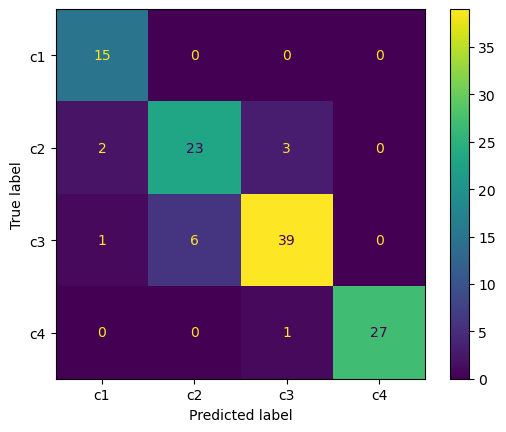

In [13]:
predictions = model.predict(data_test)
cm = confusion_matrix(target_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [14]:
generator_ordinal=data_train.loc[:,'Week5_Covid':'Week2_Mobility']
generator_ordinal= enc.fit_transform(generator_ordinal)

In [15]:
generator_ordinal

array([[1., 1., 2., ..., 4., 4., 1.],
       [3., 3., 3., ..., 2., 3., 3.],
       [3., 3., 3., ..., 3., 2., 2.],
       ...,
       [3., 4., 4., ..., 4., 4., 4.],
       [3., 4., 4., ..., 4., 4., 3.],
       [1., 2., 2., ..., 3., 3., 3.]])

In [16]:
generator_numerical_df=data_train.loc[:,'Days_passed':'Duration']

In [17]:
generator_numerical=generator_numerical_df.values

In [18]:
generator_numerical

array([[ 42.,   7.],
       [322.,  35.],
       [329.,  21.],
       [357.,  49.],
       [ 42.,  21.],
       [301.,  56.],
       [ 70.,  70.],
       [245.,  28.],
       [273.,  35.],
       [273.,  49.],
       [273.,  28.],
       [273.,  21.],
       [392.,  14.],
       [182.,  28.],
       [ 77.,  98.],
       [105.,  28.],
       [161.,  14.],
       [147.,   7.],
       [ 49.,  28.],
       [147.,  56.],
       [175.,  28.],
       [434.,  14.],
       [364.,  49.],
       [378.,  14.],
       [357.,  21.],
       [147.,  21.],
       [ 49.,  28.],
       [ 63.,  56.],
       [280.,  42.],
       [357.,  91.],
       [266.,  35.],
       [434.,  14.],
       [273.,  28.],
       [322.,  28.],
       [308.,  42.],
       [273.,  49.],
       [378.,  49.],
       [175.,  21.],
       [147.,  14.],
       [399.,  28.],
       [364.,  84.],
       [ 49., 119.],
       [126.,  14.],
       [154.,  21.],
       [ 49.,  14.],
       [301.,  49.],
       [406.,  42.],
       [287.,

In [19]:
generator_data=np.append(generator_ordinal,generator_numerical, axis=1)

In [20]:
generator_data

array([[  1.,   1.,   2., ...,   1.,  42.,   7.],
       [  3.,   3.,   3., ...,   3., 322.,  35.],
       [  3.,   3.,   3., ...,   2., 329.,  21.],
       ...,
       [  3.,   4.,   4., ...,   4., 273.,  28.],
       [  3.,   4.,   4., ...,   3., 273.,  21.],
       [  1.,   2.,   2., ...,   3., 168.,  28.]])

### Generator

In [21]:
import random
class NewGen:
    def __init__(self):
        self.gen_data = None
 
    def perturb(self, x, num_instances):
        perturbed_arrays = []
        for _ in range(num_instances):
            perturbed_arr = x[:]
 
            # Initial probabilities based on the initial data
            probabilities_covid = [0.0, 0.25, 0.13, 0.36, 0.26]
            probabilities_mobility = [0.0, 0.12, 0.18, 0.45, 0.24]
            choices = [0, 1, 2, 3, 4]
 
 
            for val in range(0,3): #covid
                if val == 0:
                    perturbed_arr[val] = random.choices(choices, weights = probabilities_covid)[0]
                else:
                    probabilities_covid = [0.0, 0.4, 0.3, 0.2, 0.1] if perturbed_arr[val-1]==1 else [0.0, 0.25, 0.4, 0.25, 0.1] if perturbed_arr[val-1]==2 else [0.0, 0.1, 0.25, 0.4, 0.25] if perturbed_arr[val-1]==3 else [0.0, 0.1, 0.2, 0.3, 0.4]
                    perturbed_arr[val] = random.choices(choices, weights = probabilities_covid)[0]
            for val in range(3, 7): #mobility
                if val == 3:
                    perturbed_arr[val] = random.choices(choices, weights = probabilities_mobility)[0]
                else:
                    probabilities_mobility = [0.0, 0.4, 0.3, 0.2, 0.1] if perturbed_arr[val-1]==1 else [0.0, 0.25, 0.4, 0.25, 0.1] if perturbed_arr[val-1]==2 else [0.0, 0.1, 0.25, 0.4, 0.25] if perturbed_arr[val-1]==3 else [0.0, 0.1, 0.2, 0.3, 0.4]
                    perturbed_arr[val] = random.choices(choices, weights = probabilities_mobility)[0]
                    
            perturbed_arr[7]= random.choice(range(42, 442, 7)) 
            perturbed_arr[8]= random.choice(range(7, 148, 7))
                
 
 
            perturbed_arrays.append(perturbed_arr)
        self.gen_data = perturbed_arrays
        return perturbed_arrays
 
 
# Example usage:
 
 
x =list(generator_data[95])
perturber = NewGen()
n = 100
perturbed_arrays = perturber.perturb(x=x, num_instances=n)
for perturbed_arr in perturbed_arrays:
    print(perturbed_arr)

[4, 3, 3, 3, 3, 4, 3, 161, 112]
[2, 1, 3, 4, 4, 4, 3, 336, 84]
[2, 1, 1, 1, 1, 1, 2, 385, 56]
[4, 4, 3, 4, 2, 2, 3, 308, 77]
[4, 4, 2, 3, 3, 3, 1, 203, 49]
[3, 3, 2, 1, 1, 1, 2, 154, 70]
[4, 2, 1, 3, 2, 2, 4, 154, 119]
[2, 2, 1, 4, 2, 1, 3, 70, 42]
[1, 1, 2, 1, 2, 3, 2, 420, 105]
[4, 4, 3, 2, 1, 2, 2, 315, 49]
[4, 4, 4, 2, 2, 2, 3, 287, 14]
[3, 3, 4, 3, 1, 2, 3, 182, 28]
[1, 3, 2, 1, 2, 3, 3, 42, 133]
[3, 3, 3, 4, 2, 3, 2, 287, 77]
[1, 1, 3, 1, 3, 4, 1, 168, 147]
[1, 4, 1, 1, 1, 2, 3, 350, 56]
[3, 3, 3, 1, 1, 3, 3, 49, 56]
[4, 4, 4, 3, 3, 2, 1, 154, 56]
[4, 1, 1, 3, 2, 4, 4, 266, 126]
[3, 1, 3, 4, 4, 1, 3, 434, 56]
[2, 2, 4, 4, 2, 2, 3, 350, 14]
[3, 4, 4, 3, 4, 3, 2, 315, 28]
[1, 2, 2, 2, 2, 1, 2, 343, 49]
[2, 3, 2, 3, 4, 3, 2, 322, 91]
[4, 4, 3, 4, 2, 2, 2, 364, 126]
[4, 3, 3, 3, 3, 4, 4, 91, 105]
[4, 4, 4, 4, 2, 2, 3, 105, 140]
[3, 3, 2, 3, 2, 1, 4, 161, 21]
[3, 2, 2, 3, 3, 2, 1, 350, 70]
[3, 2, 1, 4, 4, 4, 1, 175, 91]
[4, 4, 4, 3, 3, 3, 3, 42, 63]
[3, 3, 2, 2, 2, 2, 1, 133, 70]
[4, 

In [22]:
columns=X_feat.columns

In [23]:
columns

Index(['Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week5_Mobility',
       'Week4_Mobility', 'Week3_Mobility', 'Week2_Mobility', 'Days_passed',
       'Duration'],
      dtype='object')

In [24]:
neighbour_df_95 = pd.DataFrame(perturbed_arrays, columns=columns)
neighbour_df_95.head()

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,4,3,3,3,3,4,3,161,112
1,2,1,3,4,4,4,3,336,84
2,2,1,1,1,1,1,2,385,56
3,4,4,3,4,2,2,3,308,77
4,4,4,2,3,3,3,1,203,49


We now use the black box we created before to classify all the instances of the new synthetic dataset

In [27]:
neighbour_df_95.to_csv('../../datasets/neighbourhood_95.csv', index=False)  
neighbour=TabularDataset.from_csv('../../datasets/neighbourhood_95.csv')

2024-05-23 11:00:49,510 root         WARNING  No target class is defined
2024-05-23 11:00:49,513 root         INFO     ../../datasets/neighbourhood_95.csv file imported


In [44]:
decoded_data = enc.inverse_transform(neighbour.df.values)

ValueError: Shape of the passed X data is not correct. Expected 7 columns, got 9.

In [28]:
from lore_sa.bbox import sklearn_classifier_bbox

In [29]:
bbox = sklearn_classifier_bbox.sklearnBBox(model)

In [32]:
neighbour.df

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,4,3,3,3,3,4,3,161,112
1,2,1,3,4,4,4,3,336,84
2,2,1,1,1,1,1,2,385,56
3,4,4,3,4,2,2,3,308,77
4,4,4,2,3,3,3,1,203,49
...,...,...,...,...,...,...,...,...,...
95,1,4,3,3,3,3,4,350,77
96,3,3,3,4,2,4,4,189,14
97,3,3,3,3,4,3,3,105,105
98,3,2,2,2,4,4,4,217,84


In [38]:
neighbour.df.dtypes

Week5_Covid       int64
Week4_Covid       int64
Week3_Covid       int64
Week5_Mobility    int64
Week4_Mobility    int64
Week3_Mobility    int64
Week2_Mobility    int64
Days_passed       int64
Duration          int64
dtype: object

In [39]:
print(neighbour.df.isna().sum())
print(neighbour.df.isin([np.inf, -np.inf]).sum())

Week5_Covid       0
Week4_Covid       0
Week3_Covid       0
Week5_Mobility    0
Week4_Mobility    0
Week3_Mobility    0
Week2_Mobility    0
Days_passed       0
Duration          0
dtype: int64
Week5_Covid       0
Week4_Covid       0
Week3_Covid       0
Week5_Mobility    0
Week4_Mobility    0
Week3_Mobility    0
Week2_Mobility    0
Days_passed       0
Duration          0
dtype: int64


In [35]:
neighbour.df['Class_label'] = bbox.predict(neighbour.df)

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
neighbour.set_class_name('Class_label')

In [64]:
neighbour_df_95.to_csv('../../datasets/neighbourhood_95.csv', index=False) 